Numerosity Reduction (Breast Cancer Dataset)


In [2]:
!pip install  imblearn

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [i

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, recall_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler


In [4]:
columns = ['ID', 'Diagnosis',
           'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
           'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean',
           'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se',
           'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
           'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
           'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst',
           'symmetry_worst', 'fractal_dimension_worst']


In [6]:
import pandas as pd


data_path = r"C:\Users\harsh\Downloads\breast+cancer+wisconsin+diagnostic (1)\wdbc.data"

df = pd.read_csv(data_path, header=None, names=columns)


In [7]:
print(df.head())
print(df['Diagnosis'].value_counts())


         ID Diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

Class distribution:
Diagnosis
0    357
1    212
Name: count, dtype: int64


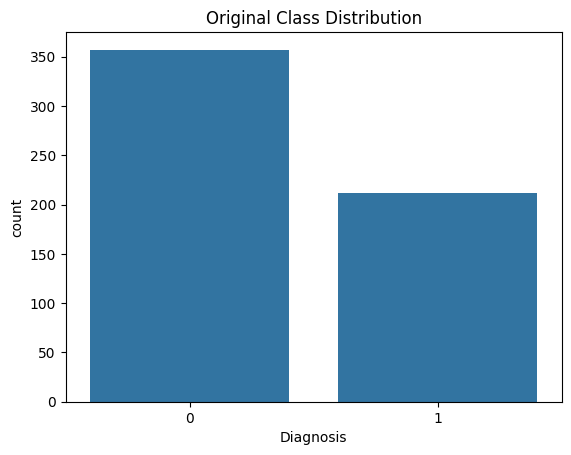

In [9]:
# Drop ID column if exists (case-sensitive)
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

# Encode target: M=1 (malignant), B=0 (benign)
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

# Features and target
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

print("Class distribution:")
print(y.value_counts())

# Visualize class imbalance
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Original Class Distribution")
plt.show()


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)


In [11]:
def evaluate_model(X_train, y_train, X_test, y_test, label):
    model = GradientBoostingClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    print(f"\n--- {label} ---")
    print("F1-score:", round(f1,3))
    print("Recall:", round(recall,3))
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
    plt.title(f"Confusion Matrix ({label})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return f1, recall



--- Original Imbalanced Data ---
F1-score: 0.951
Recall: 0.906
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



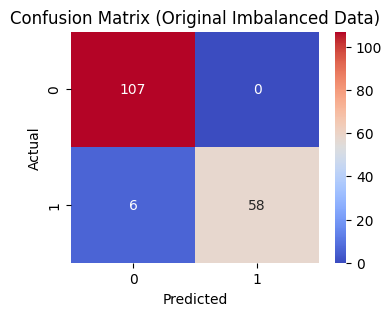

In [12]:
f1_orig, recall_orig = evaluate_model(X_train, y_train, X_test, y_test, "Original Imbalanced Data")



--- SMOTE Oversampling ---
F1-score: 0.959
Recall: 0.922
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



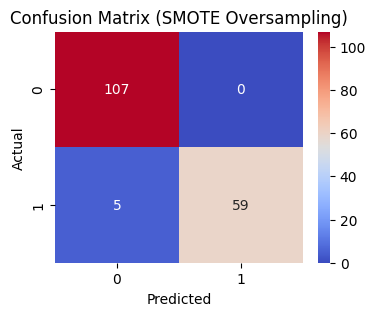

In [13]:
sm = SMOTE(sampling_strategy=0.6, random_state=42)
X_sm, y_sm = sm.fit_resample(X_train, y_train)
f1_sm, recall_sm = evaluate_model(X_sm, y_sm, X_test, y_test, "SMOTE Oversampling")


In [17]:
print(y_train.value_counts())


Diagnosis
0    250
1    148
Name: count, dtype: int64


In [18]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(sampling_strategy=1.0, random_state=42)
X_ada, y_ada = adasyn.fit_resample(X_train, y_train)



--- ADASYN Oversampling ---
F1-score: 0.969
Recall: 0.969
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       107
           1       0.97      0.97      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



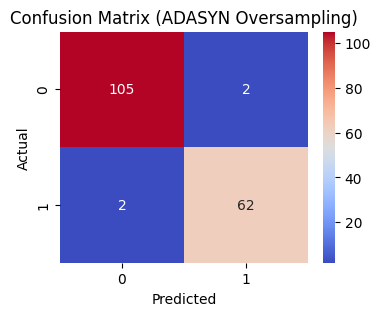

In [19]:
f1_ada, recall_ada = evaluate_model(X_ada, y_ada, X_test, y_test, "ADASYN Oversampling")


In [20]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(sampling_strategy=1.0, random_state=42)
X_ada, y_ada = adasyn.fit_resample(X_train, y_train)



--- Random Undersampling ---
F1-score: 0.951
Recall: 0.906
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



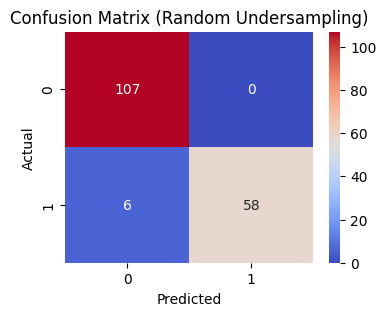

In [21]:
rus = RandomUnderSampler(sampling_strategy=0.6, random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
f1_rus, recall_rus = evaluate_model(X_rus, y_rus, X_test, y_test, "Random Undersampling")


                 Method  F1-score    Recall
0              Original   0.95082  0.906250
1                 SMOTE   0.95935  0.921875
2                ADASYN   0.96875  0.968750
3  Random Undersampling   0.95082  0.906250


C:\Users\harsh\AppData\Local\Temp\ipykernel_3536\1136467508.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='F1-score', data=results, palette='viridis', ax=ax[0])
C:\Users\harsh\AppData\Local\Temp\ipykernel_3536\1136467508.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Recall', data=results, palette='magma', ax=ax[1])


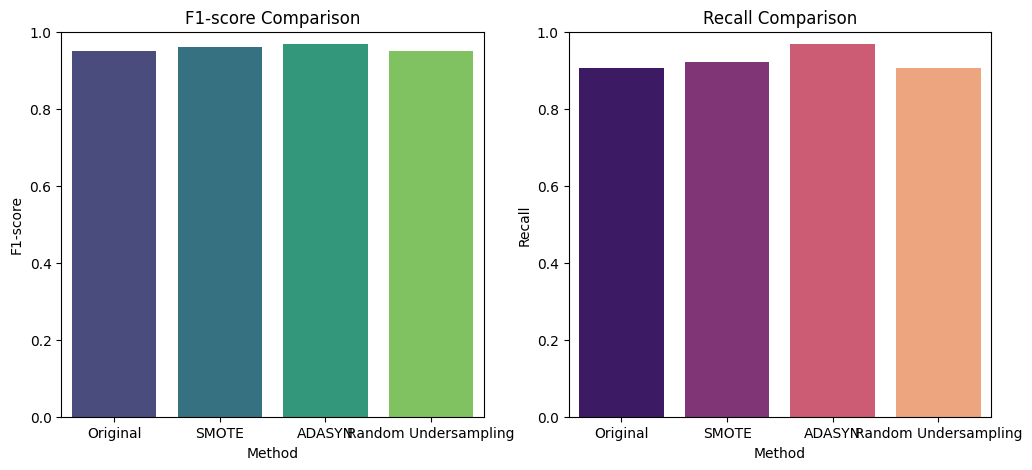

In [24]:
results = pd.DataFrame({
    'Method': ['Original', 'SMOTE', 'ADASYN', 'Random Undersampling'],
    'F1-score': [f1_orig, f1_sm, f1_ada, f1_rus],
    'Recall': [recall_orig, recall_sm, recall_ada, recall_rus]
})

print(results)

# Plot comparison
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.barplot(x='Method', y='F1-score', data=results, palette='viridis', ax=ax[0])
ax[0].set_title("F1-score Comparison")
ax[0].set_ylim([0,1])

sns.barplot(x='Method', y='Recall', data=results, palette='magma', ax=ax[1])
ax[1].set_title("Recall Comparison")
ax[1].set_ylim([0,1])

plt.show()


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, solver='lbfgs', multi_class='ovr')  # 'ovr' = one-vs-rest
model.fit(X_train_scaled, y_train)


C:\Users\harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'ovr'


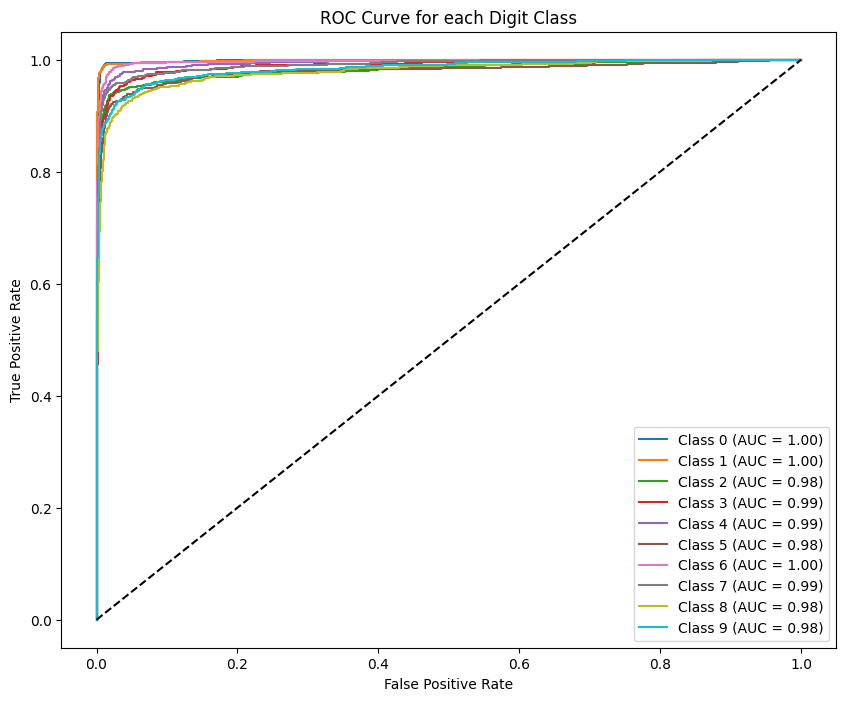

In [41]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize the output (one-hot encode labels)
y_test_bin = label_binarize(y_test, classes=np.arange(10))  # 10 classes (0-9)

# Predict probabilities for each class
y_prob = model.predict_proba(X_test_scaled)

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for each Digit Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Dimensionality Reduction (MNIST Dataset)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import time


In [26]:
import pandas as pd

# Use raw string (r"") or double backslashes (\\) to avoid escape issues in Windows paths
train_path = r"C:\Users\harsh\Downloads\archive (2)\mnist_train.csv"
test_path = r"C:\Users\harsh\Downloads\archive (2)\mnist_test.csv"

# Load the CSV files
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# Split features and target
X_train = train.drop('label', axis=1)
y_train = train['label']

X_test = test.drop('label', axis=1)
y_test = test['label']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (60000, 784)
Test shape: (10000, 784)


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [28]:
knn = KNeighborsClassifier(n_neighbors=5)

start_time = time.time()
knn.fit(X_train_scaled, y_train)
acc_before = knn.score(X_test_scaled, y_test)
time_before = time.time() - start_time

print(f"Accuracy before PCA: {acc_before:.4f}")
print(f"Computation time before PCA: {time_before:.2f} seconds")


Accuracy before PCA: 0.9443
Computation time before PCA: 15.78 seconds


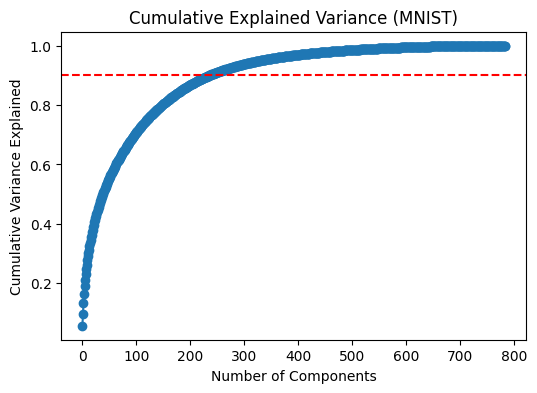

Number of PCA components for 90% variance: 236


In [29]:
pca = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(cumulative_variance, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.title("Cumulative Explained Variance (MNIST)")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.show()

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of PCA components for 90% variance: {n_components_90}")


In [30]:
pca = PCA(n_components=n_components_90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [31]:
pca = PCA(n_components=n_components_90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [32]:
knn = KNeighborsClassifier(n_neighbors=5)

start_time = time.time()
knn.fit(X_train_pca, y_train)
acc_after = knn.score(X_test_pca, y_test)
time_after = time.time() - start_time

print(f"Accuracy after PCA: {acc_after:.4f}")
print(f"Computation time after PCA: {time_after:.2f} seconds")


Accuracy after PCA: 0.9543
Computation time after PCA: 4.98 seconds


In [33]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Computation Time (s)', 'No. of Features'],
    'Before PCA': [acc_before, time_before, X_train.shape[1]],
    'After PCA': [acc_after, time_after, n_components_90]
})

print(results)


                 Metric  Before PCA   After PCA
0              Accuracy    0.944300    0.954300
1  Computation Time (s)   15.782404    4.976341
2       No. of Features  784.000000  236.000000


C:\Users\harsh\AppData\Local\Temp\ipykernel_3536\3691008321.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Before PCA', 'After PCA'], y=[acc_before, acc_after], ax=ax1[0], palette='viridis')
C:\Users\harsh\AppData\Local\Temp\ipykernel_3536\3691008321.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Before PCA', 'After PCA'], y=[time_before, time_after], ax=ax1[1], palette='magma')


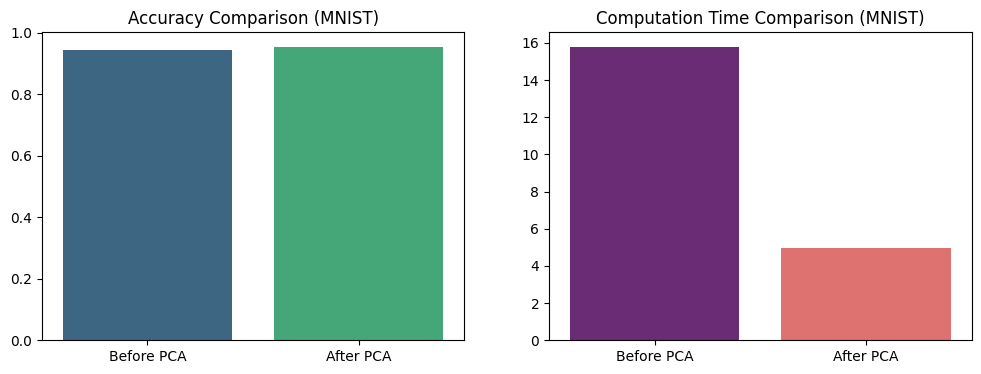

In [34]:
fig, ax1 = plt.subplots(1,2, figsize=(12,4))

# Accuracy comparison
sns.barplot(x=['Before PCA', 'After PCA'], y=[acc_before, acc_after], ax=ax1[0], palette='viridis')
ax1[0].set_title("Accuracy Comparison (MNIST)")

# Computation time comparison
sns.barplot(x=['Before PCA', 'After PCA'], y=[time_before, time_after], ax=ax1[1], palette='magma')
ax1[1].set_title("Computation Time Comparison (MNIST)")

plt.show()


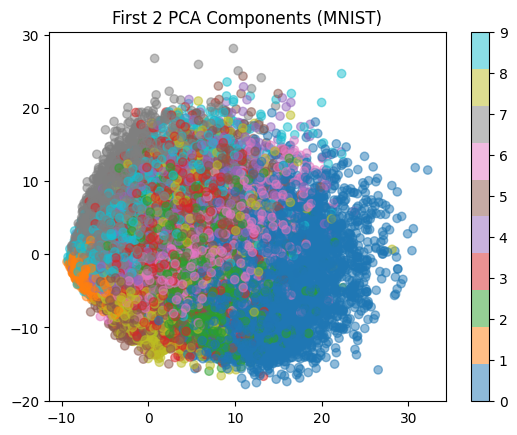

In [36]:
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='tab10', alpha=0.5)
plt.colorbar()
plt.title("First 2 PCA Components (MNIST)")
plt.show()


Train shape: (60000, 784)
Test shape: (10000, 784)
Before PCA: k=3 -> Accuracy: 0.9452, Time: 15.27s
Before PCA: k=5 -> Accuracy: 0.9443, Time: 15.55s
Before PCA: k=7 -> Accuracy: 0.9433, Time: 15.54s


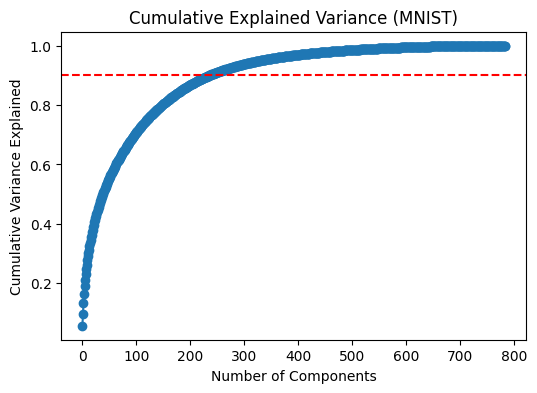

Number of PCA components for 90% variance: 236
After PCA: k=3 -> Accuracy: 0.9538, Time: 4.95s
After PCA: k=5 -> Accuracy: 0.9543, Time: 5.02s
After PCA: k=7 -> Accuracy: 0.9511, Time: 4.99s


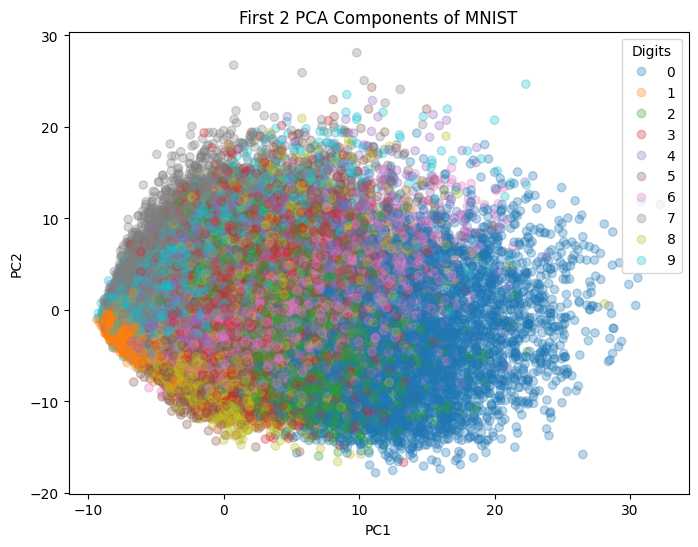

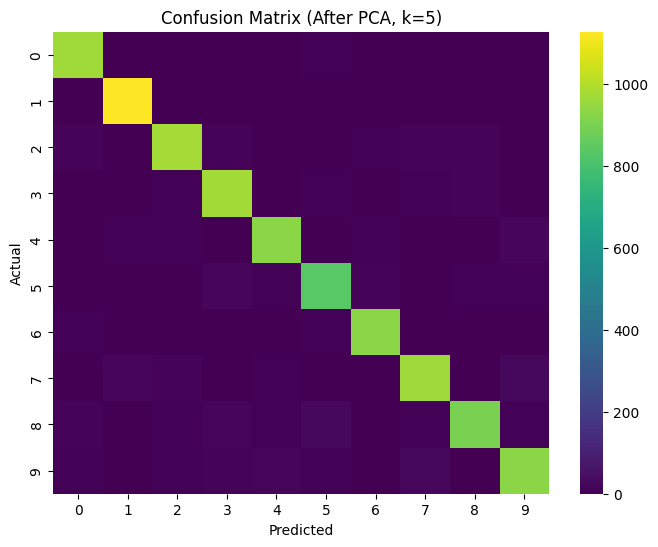

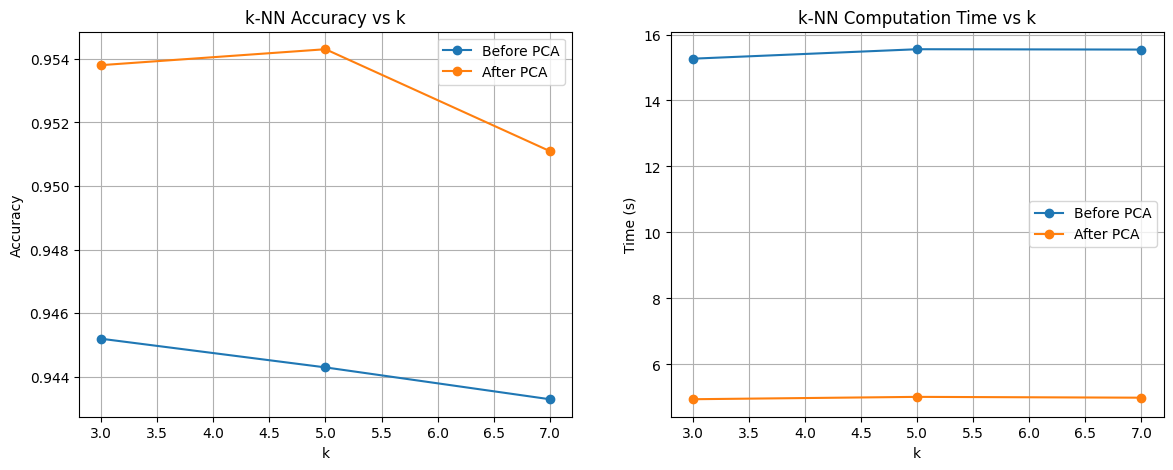

In [42]:
# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import time

# 2️⃣ Load Dataset with full paths (use raw strings for Windows paths)
train = pd.read_csv(r"C:\Users\harsh\Downloads\archive (2)\mnist_train.csv")
test = pd.read_csv(r"C:\Users\harsh\Downloads\archive (2)\mnist_test.csv")

X_train = train.drop('label', axis=1)
y_train = train['label']
X_test = test.drop('label', axis=1)
y_test = test['label']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# 3️⃣ Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4️⃣ k-NN Before PCA (Multiple k values)
k_values = [3, 5, 7]
acc_before_list = []
time_before_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    start = time.time()
    knn.fit(X_train_scaled, y_train)
    acc = knn.score(X_test_scaled, y_test)
    duration = time.time() - start
    acc_before_list.append(acc)
    time_before_list.append(duration)
    print(f"Before PCA: k={k} -> Accuracy: {acc:.4f}, Time: {duration:.2f}s")

# 5️⃣ PCA to Retain 90% Variance
pca_full = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(cumulative_variance, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.title("Cumulative Explained Variance (MNIST)")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.show()

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of PCA components for 90% variance: {n_components_90}")

# 6️⃣ Transform Data Using PCA
pca = PCA(n_components=n_components_90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 7️⃣ k-NN After PCA (Multiple k values)
acc_after_list = []
time_after_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    start = time.time()
    knn.fit(X_train_pca, y_train)
    acc = knn.score(X_test_pca, y_test)
    duration = time.time() - start
    acc_after_list.append(acc)
    time_after_list.append(duration)
    print(f"After PCA: k={k} -> Accuracy: {acc:.4f}, Time: {duration:.2f}s")

# 8️⃣ Scatter Plot of First 2 PCA Components
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='tab10', alpha=0.3)
plt.legend(*scatter.legend_elements(), title="Digits")
plt.title("First 2 PCA Components of MNIST")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 9️⃣ Confusion Matrix Heatmap (Example k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, fmt='d', cmap='viridis')
plt.title("Confusion Matrix (After PCA, k=5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🔟 Accuracy & Computation Time Comparison Plots
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
ax[0].plot(k_values, acc_before_list, marker='o', label='Before PCA')
ax[0].plot(k_values, acc_after_list, marker='o', label='After PCA')
ax[0].set_title("k-NN Accuracy vs k")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].grid(True)

# Computation Time
ax[1].plot(k_values, time_before_list, marker='o', label='Before PCA')
ax[1].plot(k_values, time_after_list, marker='o', label='After PCA')
ax[1].set_title("k-NN Computation Time vs k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Time (s)")
ax[1].legend()
ax[1].grid(True)

plt.show()
